In [1]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from joblib import Parallel, delayed
from matplotlib.lines import Line2D
from pandas.tseries.offsets import MonthEnd
from scipy.optimize import minimize
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as root_mse
from tqdm import tqdm

os.makedirs("output", exist_ok=True)
sns.set(style="white")

# Données

In [2]:
model_data = pd.read_parquet("data/model_data.parquet")
model_data_no_journal = pd.read_parquet("data/model_data_njl.parquet")
nuances_order = ["Far right", "Right", "Center", "Left", "Far left", "Other"]

In [3]:
presi_dates = [
    "26/04/1981", "10/05/1981",
    "24/04/1988", "08/05/1988",
    "23/04/1995", "07/05/1995",
    "21/04/2002", "05/05/2002",
    "22/04/2007", "06/05/2007",
    "22/04/2012", "06/05/2012",
    "21/04/2017", "07/05/2017",
    "10/04/2022", "24/04/2022"]
presi_months = pd.to_datetime(presi_dates, dayfirst=True).to_period('M').drop_duplicates()

legi_dates = [
    "14/06/1981", "21/06/1981",
    "16/03/1986",
    "05/06/1988", "11/06/1988",
    "21/03/1993", "28/03/1993",
    "25/05/1997", "01/06/1997",
    "09/06/2002", "16/06/2002",
    "10/06/2007", "17/06/2007",
    "10/06/2012", "17/06/2012",
    "11/06/2017", "18/06/2017",
    "12/06/2022", "19/06/2022",
    "29/06/2024", "06/07/2024"]
legi_months = pd.to_datetime(legi_dates, dayfirst=True).to_period('M').drop_duplicates()

europ_dates = [
    "17/06/1984",
    "18/06/1989",
    "12/06/1994",
    "13/06/1999",
    "13/06/2004",
    "07/06/2009",
    "25/05/2014",
    "26/05/2019",
    "09/06/2024"]
europ_months = pd.to_datetime(europ_dates, dayfirst=True).to_period('M').drop_duplicates()

main_elec_dates = presi_dates + legi_dates + europ_dates
main_elec_months = pd.to_datetime(main_elec_dates, dayfirst=True).to_period('M').drop_duplicates().sort_values()

def add_shaded_periods(ax_list, periods, color, alpha):
    start_period = None
    for i, period in enumerate(periods):
        if start_period is None:
            start_period = period
        is_last = (i == len(periods) - 1)
        is_gap = (not is_last and periods[i + 1] != period + 1)
        if is_last or is_gap:
            end_period = period
            start = start_period.to_timestamp()
            end = (end_period + MonthEnd(1)).to_timestamp()
            for ax in ax_list:
                ax.axvspan(start, end, color=color, alpha=alpha)
            start_period = None

In [4]:
outcome = "quotes_share"

# 1. Méthode

## Modèle

L'organisation du système politique français fait que la couverture médiatique de la vie politique à l'échelle nationale est structurée par le cycle des élections présidentielles. On décompose celui-ci en trois périodes répondant à des logiques différentes (= où la norme de représentativité s'incarne différemment) :
- Période inter-électorale, où la couverture médiatique des nuances politiques dépend de leur importance électorale et institutionnelle
- Période pré-électorale, correspondant à la campagne électorale jusqu'au premier tour de l'élection présidentielle, où les sondages prennent un poids croissant
- Période post-électorale, recouvrant le second tour de l'élection présidentielle et les élections législatives

Indiçons par $i$ les nuances politiques ($n$ au total) et $t$ les périodes, puis notons $Y_{it}$ la proportion des citations reçues par la nuance $i$ à la période $t$ et $Y_{it}^{norm}$ qu'elle devrait normalement recevoir. Les modèles sont formulés de manière à respecter les contraintes de compositionnalité pour des coefficients compris entre 0 et 1.

**Période inter-électorale**

Supposons qu'à chaque période :
- Chaque nuance reçoit une fraction incompressible des citations, c'est-à-dire qu'elle bénéficie d'une couverture médiatique minimale même lorsque son poids électoral et institutionnel est nul. Cette fraction est notée $\alpha$.
- La nuance politique au gouvernement reçoit une fraction fixe des citations, notée $\theta$, reflétant la couverture médiatique de l'action gouvernementale (en notant $G_{it}$ l'indicatrice valant 1 si le Premier ministre appartient à la nuance politique $i$ durant la période $t$).
- Les citations restantes sont réparties entre les nuances politiques en fonction de leur poids dans la vie politique, estimé par la moyenne pondérée de la proportion des sièges qu'elles détiennent à l'Assemblée nationale (notée ${AN}_{it}$ et pondérée par $\beta$) et du score qu'elles ont obtenu au premier tour de la dernière élection présidentielle (notée $P_{it}$ et pondérée par $\gamma$).
  - Pourquoi le premier tour des présidentielles : élection reflétant le mieux les préférences politiques des Français, avec des candidats identiques sur l'ensemble du territoire, une participation très élevée... On retient ici la nuance politique des candidats.
  - Pourquoi l'AN : parce que centrale dans le fonctionnement des institutions. On retient ici la nuance politique des groupes parlementaires (plutôt que des élus).

$$Y_{it}^{norm} = \alpha + (1 - n\alpha - \theta)(\beta {AN}_{it} + \gamma P_{it}) + \theta G_{it}$$

**Période pré-électorale (janvier-avril ou novembre-avril)**

Le modèle précédent continue à fournir une valeur de référence, mais la couverture médiatique intègre aussi les résultats des sondages. On considère que le poids de ces dernier est susceptible de varier avec l'éloignement du premier tour, reflétée par $e$ : $e=0$ en avril, $e=3$ en janvier par exemple. Typiquement, on s'attendrait à voir le poids des sondages augmenter à proximité de l'élection.

$$Y_{it}^{norm} = \alpha + \delta_t^e \bigr[(1 - n\alpha - \theta)(\beta {AN}_{it} + \gamma P_{it}) + \theta G_{it}\bigr] + (1 - \delta_t^e) S_{it}$$

Effet prévisible de ce modèle : la couverture médiatique des nuances dominantes diminue en période électorale, même lorsque les sondages les créditent d'un score meilleur que lors de l'élection précédente. En effet, les modalités des élections législatives font que la domination de ces nuances est plus marquée à l'Assemblée Nationale, mais le poids de cette dernière dans le modèle est diminué par $\delta_t^e$. C'est un phénomène parfaitement attendu : en période électorale, les médias doivent laisser une place accrue aux nuances politiques marginales, en considérant leur importance politique et institutionnelle *potentielle*.

**Période post-électorale (mai-juin)**

Il s'agit ici de traiter le décalage entre les élections présidentielles et législatives, qui ne permet pas de calculer une nouvelle valeur de référence à l'issue du premier tour des premières, en évitant de générer des discontinuités dans les valeurs normales.

On considère que la couverture médiatique est dominée par les résultats du premier tour : les 2 nuances arrivées en tête reçoivent une fraction fixe des citations, tandis que les citations restantes sont réparties entre les nuances en fonction de leur score. En notant $P_{it}^{p1}$ la proportion des voix obtenues au premier tour et $P_{it}^{r2}$ l'indicatrice valant 1 si le parti $i$ est arrivé au rang $r$ au second tour, on obtient :

$$Y_{it}^{norm} = \alpha + (1 - n\alpha - \lambda_1 - \lambda_2)P_{it}^{p_1} + \sum_{r=1}^{2} \lambda_{r} P_{it}^{r_2}$$

**Modèle global**

Formellement, on note $D_t^e$ une indicatrice valant 1 si le mois $t$ se trouve en position $e$ dans le cycle électoral ($e \in [-5,E]$ en faisant démarrer le cycle le mois du premier tour, et pour d'une durée de $E$ mois, avec $E=84$ jusqu'en 2002 et $60$ ensuite). On estime alors :
$$Y_{it}^{norm} = \alpha + \sum_{e=-5}^{0} D_t^e \Bigr[\delta_t^e \bigr[(1 - n\alpha - \theta)(\beta {AN}_{it} + \gamma P_{it}) + \theta G_{it}\bigr] + (1 - \delta_t^e) S_{it}\Bigr] + \sum_{e=1}^{2} D_t^e \Bigr[(1 - n\alpha - \lambda_1 - \lambda_2)P_{it}^{p_1} + \sum_{r=1}^{2} \lambda_{r} P_{it}^{r_2} \Bigr] + \sum_{e=3}^{E-6} D_t^e \Bigr[(1 - n\alpha - \theta)(\beta {AN}_{it} + \gamma P_{it}) + \theta G_{it} \Bigr]$$

Estimation impossible avec les OLS car le modèle n'est pas linéaire pour certains paramètres, et ne permettrait pas d'assurer le respect des contraintes de compositionnalité. On procède donc plutôt à une optimisation sous contraintes : on minimise l'erreur quadratique moyenne (i.e., $\sum_{i,t} (Y_{it} - Y_{it}^{norm})^2$) en imposant que tous les coefficients soient compris entre 0 et 1.

Plusieurs différences notables avec les OLS :
- Il n'est pas acquis qu'une solution existe
- Les résidus ne seront pas nécessairement centrés
- Les approximations asymptotiques ne sont pas valables, il faut utiliser le bootstrapping pour évaluer la validité des coefficients

In [5]:
def mean_r(y_true, y_pred):
    return (y_true - y_pred).mean()

In [6]:
def compute_y_pred(
    df,
    n, alpha, beta, gamma, theta,
    delta_pre_5, delta_pre_4, delta_pre_3, delta_pre_2, delta_pre_1, delta_pre_0,
    lambda_1, lambda_2):
    
    baseline = (
        beta * (1 - n * alpha - theta) * df["na_share"] +
        gamma * (1 - n * alpha - theta) * df["pres_votes_share"] +
        theta * df["government"])

    y_pred = (
        alpha +
        df["inter_dum"] * baseline +
        df["pre_5"] * (delta_pre_5 * baseline + (1 - delta_pre_5) * df["pres_poll_result"]) +
        df["pre_4"] * (delta_pre_4 * baseline + (1 - delta_pre_4) * df["pres_poll_result"]) +
        df["pre_3"] * (delta_pre_3 * baseline + (1 - delta_pre_3) * df["pres_poll_result"]) +
        df["pre_2"] * (delta_pre_2 * baseline + (1 - delta_pre_2) * df["pres_poll_result"]) +
        df["pre_1"] * (delta_pre_1 * baseline + (1 - delta_pre_1) * df["pres_poll_result"]) +
        df["pre_0"] * (delta_pre_0 * baseline + (1 - delta_pre_0) * df["pres_poll_result"]) +
        df["post_dum"] * (
            (1 - n * alpha - lambda_1 - lambda_2) * df["pres_votes_share"] +
            lambda_1 * df["r2_rank_1"] +
            lambda_2 * df["r2_rank_2"]))

    return y_pred

In [7]:
def objective(params, data_opt, y_opt):
    alpha = params[0]
    beta = params[1]
    gamma = 1 - beta
    theta = params[2]
    delta_pre_5, delta_pre_4, delta_pre_3, delta_pre_2, delta_pre_1, delta_pre_0 = params[3:9]
    lambda_1, lambda_2 = params[9:11]

    y_pred = compute_y_pred(
        data_opt,
        n, alpha, beta, gamma, theta,
        delta_pre_5, delta_pre_4, delta_pre_3, delta_pre_2, delta_pre_1, delta_pre_0,
        lambda_1, lambda_2)

    return root_mse(y_opt, y_pred)

# Initial guess for the coefficients: alpha, beta, theta, delta_pre_5 to delta_pre_0, lambda_1 and lambda_2
initial_guess = [0.01, 0.7, 0.2, 0.9, 0.85, 0.8, 0.7, 0.5, 0.2, 0.15, 0.1]

# Bounds: all coefficients between 0 and 1
bounds = [(0, 1)] * 11

# Constraints: increasing poll weights during electoral campaigns
constraints = [
    {"type": "ineq", "fun": lambda x: x[3] - x[4]},  # delta_pre_5 > delta_pre_4
    {"type": "ineq", "fun": lambda x: x[4] - x[5]},  # delta_pre_4 > delta_pre_3
    {"type": "ineq", "fun": lambda x: x[5] - x[6]},  # delta_pre_3 > delta_pre_2
    {"type": "ineq", "fun": lambda x: x[6] - x[7]},  # delta_pre_2 > delta_pre_1
    {"type": "ineq", "fun": lambda x: x[7] - x[8]},  # delta_pre_1 > delta_pre_0
]

# Number of political nuances
n = len(model_data_no_journal['political_alignment'].unique())

### Sur l'ensemble des données

In [8]:
data_opt = model_data_no_journal[
    ["inter_dum", "pre_5", "pre_4", "pre_3", "pre_2", "pre_1", "pre_0", "post_dum", 
     "na_share", "pres_votes_share", "government", "pres_poll_result", "r2_rank_1", "r2_rank_2"]]

y_opt = model_data_no_journal[outcome]

result = minimize(objective, initial_guess, args=(data_opt, y_opt), bounds=bounds, constraints=[], method='SLSQP')
# result = minimize(objective, initial_guess, args=(data_opt, y_opt), bounds=bounds, constraints=constraints, method='SLSQP')

if result.success:
    alpha, beta, theta, delta_pre_5, delta_pre_4, delta_pre_3, delta_pre_2, delta_pre_1, delta_pre_0, lambda_1, lambda_2 = result.x
    gamma = 1 - beta

    print(f"Optimal alpha: {alpha:.5f}")
    print(f"Optimal beta: {beta:.5f}")
    print(f"Optimal gamma: {gamma:.5f}")
    print(f"Optimal theta: {theta:.5f}")
    print(f"Optimal delta_pre_5: {delta_pre_5:.5f}")
    print(f"Optimal delta_pre_4: {delta_pre_4:.5f}")
    print(f"Optimal delta_pre_3: {delta_pre_3:.5f}")
    print(f"Optimal delta_pre_2: {delta_pre_2:.5f}")
    print(f"Optimal delta_pre_1: {delta_pre_1:.5f}")
    print(f"Optimal delta_pre_0: {delta_pre_0:.5f}")
    print(f"Optimal lambda_1: {lambda_1:.5f}")
    print(f"Optimal lambda_2: {lambda_2:.5f}")
else:
    print("Optimization failed:", result.message)

Optimal alpha: 0.00000
Optimal beta: 0.80761
Optimal gamma: 0.19239
Optimal theta: 0.08104
Optimal delta_pre_5: 0.78331
Optimal delta_pre_4: 0.86186
Optimal delta_pre_3: 0.89910
Optimal delta_pre_2: 0.62249
Optimal delta_pre_1: 0.63934
Optimal delta_pre_0: 0.46112
Optimal lambda_1: 0.23490
Optimal lambda_2: 0.08996


On obtient un résultat inattendu : les sondages ont plus d'importance en novembre qu'en décembre et janvier. On peut l'éliminer grâce aux contraintes, mais les coefficients semblent alors un peu arbitraires :
- Optimal delta_pre_5: 0.85882
- Optimal delta_pre_4: 0.85882
- Optimal delta_pre_3: 0.85882
- Optimal delta_pre_2: 0.63645
- Optimal delta_pre_1: 0.63645
- Optimal delta_pre_0: 0.43894

Il est aussi possible de distinguer les coefficients lambda entre le mois du second tour des présidentielles et le mois des législatives, mais les résultats ne sont pas évidents à interpréter.

In [9]:
y_pred = compute_y_pred(
    data_opt,
    n, alpha, beta, gamma, theta,
    delta_pre_5, delta_pre_4, delta_pre_3, delta_pre_2, delta_pre_1, delta_pre_0,
    lambda_1, lambda_2)

r2 = r2_score(y_opt, y_pred)
mr = mean_r(y_opt, y_pred)
rmspe = root_mse(y_opt, y_pred)

print(f"R2: {100*r2:.3f}%")
print(f"MR: {100*mr:.5f}%")
print(f"RMSPE: {rmspe:.5f}")

R2: 88.500%
MR: -0.00017%
RMSPE: 0.07630


Les résidus moyens ne sont pas nuls, ce qui signifie que le modèle n'est pas centré, ou encore que les prédictions présentent un biais systématique : elles sont inférieures en moyenne aux valeurs réelles de 0,00018 points de pourcentage. Cela signifie, théoriquement, qu'il ne faut pas faire confiance au $R^2$ !

*NB: le fait que les résidus moyens ne sont pas nuls pourrait aussi témoigner de relations non-linéaires, mais c'est une possibilité que nous n'avons pas envie d'explorer, car la norme de representativité conduit à supposer des relations proportionnelles. De surcroît, les résidus moyens sont tellement faibles que les non-linéarités sont sûrement négligeables.*

Moyenne des valeurs normales : 0.1666684
Moyenne des valeurs réelles : 0.1666667

Moyenne des résidus positifs (sous-estimation) : 0.0581562
Moyenne des résidus négatifs (sur-estimation) : -0.0462348


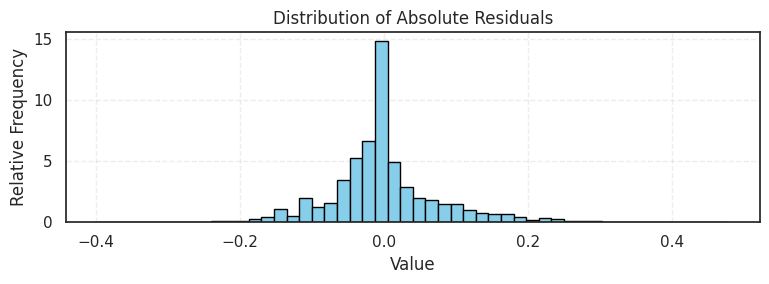

In [10]:
abs_diff = y_opt - y_pred

print(f"Moyenne des valeurs normales : {y_pred.mean():.7f}")
print(f"Moyenne des valeurs réelles : {y_opt.mean():.7f}")
print("")
print(f"Moyenne des résidus positifs (sous-estimation) : {abs_diff[abs_diff > 0].mean():.7f}")
print(f"Moyenne des résidus négatifs (sur-estimation) : {abs_diff[abs_diff < 0].mean():.7f}")

plt.figure(figsize=(8, 3))
plt.hist(abs_diff, bins=50, color='skyblue', edgecolor='black', density=True)
plt.title('Distribution of Absolute Residuals')
plt.xlabel('Value')
plt.ylabel('Relative Frequency')
plt.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

In [11]:
# Bootstrapping (on months instead of observations to respect compositionnality)
n_bootstraps = 5000
n_blocks = len(model_data_no_journal) // 6

def run_bootstrap_iteration(seed):
    np.random.seed(seed)
    sampled_block_ids = np.random.choice(n_blocks, size=n_blocks, replace=True)
    sampled_row_indices = np.concatenate([
        np.arange(block_id * 6, block_id * 6 + 6) for block_id in sampled_block_ids
    ])
    boot_data = model_data_no_journal.iloc[sampled_row_indices].reset_index(drop=True)
    boot_data = boot_data[[
        outcome,
        "political_alignment", "inter_dum", "pre_5", "pre_4", "pre_3", "pre_2", "pre_1", "pre_0", "post_dum",
        "na_share", "pres_votes_share", "government", "pres_poll_result", "r2_rank_1", "r2_rank_2"]]
    boot_y = boot_data[outcome]

    result = minimize(objective, initial_guess, args=(boot_data, boot_y), bounds=bounds, constraints=[], method='SLSQP')
    
    if result.success:
        alpha_bst, beta_bst, theta_bst, delta_pre_5_bst, delta_pre_4_bst, delta_pre_3_bst, delta_pre_2_bst, delta_pre_1_bst, delta_pre_0_bst, lambda_1_bst, lambda_2_bst = result.x
        gamma_bst = 1 - beta_bst
        return {
            "alpha": alpha_bst,
            "beta": beta_bst,
            "gamma": gamma_bst,
            "theta": theta_bst,
            "delta_pre_5": delta_pre_5_bst,
            "delta_pre_4": delta_pre_4_bst,
            "delta_pre_3": delta_pre_3_bst,
            "delta_pre_2": delta_pre_2_bst,
            "delta_pre_1": delta_pre_1_bst,
            "delta_pre_0": delta_pre_0_bst,
            "lambda_1": lambda_1_bst,
            "lambda_2": lambda_2_bst
        }
    else:
        return None

results = Parallel(n_jobs=-1)(
    delayed(run_bootstrap_iteration)(seed)
    for seed in tqdm(range(n_bootstraps), desc="Bootstrapping")
)

# Filter out failed runs (None)
bootstrap_results = [r for r in results if r is not None]

Bootstrapping: 100%|██████████| 5000/5000 [02:06<00:00, 39.51it/s]


In [12]:
# Using a one-tail approach for pvalues as coefficients are bounded by zero
bootstrap_df = pd.DataFrame(bootstrap_results)
pval = (bootstrap_df <= 0).sum() / len(bootstrap_df)
original_coeffs = pd.Series({
    "alpha": alpha,
    "beta": beta,
    "gamma": gamma,
    "theta": theta,
    "delta_pre_5": delta_pre_5,
    "delta_pre_4": delta_pre_4,
    "delta_pre_3": delta_pre_3,
    "delta_pre_2": delta_pre_2,
    "delta_pre_1": delta_pre_1,
    "delta_pre_0": delta_pre_0,
    "lambda_1": lambda_1,
    "lambda_2": lambda_2})


bootstrap_df = bootstrap_df.describe(percentiles=[0.025, 0.5, 0.975]).T
bootstrap_df["pval"] = pval
bootstrap_df["coeff"] = original_coeffs
bootstrap_df = bootstrap_df.drop(columns = ['count', 'min', '50%', 'max'])
cols = ["coeff"] + [col for col in bootstrap_df.columns if col != "coeff"]
bootstrap_df = bootstrap_df[cols]
bootstrap_df.style

,coeff,mean,std,2.5%,97.5%,pval
alpha,0.000000,0.000000,0.000000,0.000000,0.000000,0.478600
beta,0.807610,0.807702,0.015656,0.776695,0.838016,0.000000
gamma,0.192390,0.192298,0.015656,0.161984,0.223305,0.000000
theta,0.081037,0.081492,0.012577,0.057143,0.106369,0.000000
delta_pre_5,0.783312,0.792909,0.074026,0.655354,0.941356,0.000000
delta_pre_4,0.861858,0.863708,0.064655,0.719857,0.982618,0.000000
delta_pre_3,0.899104,0.882027,0.097985,0.666239,1.000000,0.000000
delta_pre_2,0.622492,0.634907,0.125591,0.399449,0.900414,0.000000
delta_pre_1,0.639336,0.641330,0.094549,0.508478,0.900283,0.000000
delta_pre_0,0.461121,0.464076,0.140475,0.256967,0.859158,0.000000


La constante et le coefficient du parti arrivé second au premier tour de l'élection présidentielle ne sont pas significatifs.

### Pour la droite et la gauche dans *Le Monde* avant juin 2012

In [13]:
# Keeping n=6 for consistent results
cutoff = pd.Period('2012-06', freq='M')

data_opt = model_data[
    (model_data["month"] < cutoff) & 
    (model_data["journal"] == "Le Monde") &
    (model_data["political_alignment"].isin(['Right', 'Left']))
    ][["inter_dum", "pre_5", "pre_4", "pre_3", "pre_2", "pre_1", "pre_0", "post_dum", 
       "na_share", "pres_votes_share", "government", "pres_poll_result", "r2_rank_1", "r2_rank_2"]]

y_opt = model_data[
    (model_data["month"] < cutoff) & 
    (model_data["journal"] == "Le Monde") &
    (model_data["political_alignment"].isin(['Right', 'Left']))
    ][outcome]

result = minimize(objective, initial_guess, args=(data_opt, y_opt), bounds=bounds, constraints=[], method='SLSQP')
# result = minimize(objective, initial_guess, args=(data_opt, y_opt), bounds=bounds, constraints=constraints, method='SLSQP')

if result.success:
    alpha_loc, beta_loc, theta_loc, delta_pre_5_loc, delta_pre_4_loc, delta_pre_3_loc, delta_pre_2_loc, delta_pre_1_loc, delta_pre_0_loc, lambda_1_loc, lambda_2_loc = result.x
    gamma_loc = 1 - beta_loc

    print(f"Optimal alpha: {alpha_loc:.5f}")
    print(f"Optimal beta: {beta_loc:.5f}")
    print(f"Optimal gamma: {gamma_loc:.5f}")
    print(f"Optimal theta: {theta_loc:.5f}")
    print(f"Optimal delta_pre_5: {delta_pre_5_loc:.5f}")
    print(f"Optimal delta_pre_4: {delta_pre_4_loc:.5f}")
    print(f"Optimal delta_pre_3: {delta_pre_3_loc:.5f}")
    print(f"Optimal delta_pre_2: {delta_pre_2_loc:.5f}")
    print(f"Optimal delta_pre_1: {delta_pre_1_loc:.5f}")
    print(f"Optimal delta_pre_0: {delta_pre_0_loc:.5f}")
    print(f"Optimal lambda_1: {lambda_1_loc:.5f}")
    print(f"Optimal lambda_2: {lambda_2_loc:.5f}")
else:
    print("Optimization failed:", result.message)

Optimal alpha: 0.00000
Optimal beta: 0.73955
Optimal gamma: 0.26045
Optimal theta: 0.07588
Optimal delta_pre_5: 0.64818
Optimal delta_pre_4: 0.85613
Optimal delta_pre_3: 0.83590
Optimal delta_pre_2: 0.82034
Optimal delta_pre_1: 0.74599
Optimal delta_pre_0: 0.61749
Optimal lambda_1: 0.32639
Optimal lambda_2: 0.27208


Les coefficients ne sont pas très différents des précédents concernant les périodes inter-électorales. Le résultat intringuant obtenu pour les périodes électorales est encore plus marqué, avec des sondages prenant une importance en novembre qui n'est retrouvée qu'en avril. Concernant la période post-électorale, on observe une prime plus importante aux partis arrivés en tête, avec des coefficients multipliés par entre 2 et 3. Ces résultats persistent en levant séparement les restrictions sur les journaux et les nuances politiques.

In [14]:
# Performance on restricted dataset
y_pred = compute_y_pred(
    data_opt,
    n, alpha_loc, beta_loc, gamma_loc, theta_loc,
    delta_pre_5_loc, delta_pre_4_loc, delta_pre_3_loc, delta_pre_2_loc, delta_pre_1_loc, delta_pre_0_loc,
    lambda_1_loc, lambda_2_loc)

r2 = r2_score(y_opt, y_pred)
mr = mean_r(y_opt, y_pred)
rmspe = root_mse(y_opt, y_pred)

print(f"R2: {100*r2:.3f}%")
print(f"MR: {100*mr:.5f}%")
print(f"RMSPE: {rmspe:.5f}")

R2: 54.869%
MR: 4.22919%
RMSPE: 0.10790


In [15]:
# Performance on full dataset
y_pred = compute_y_pred(
    model_data_no_journal,
    n, alpha_loc, beta_loc, gamma_loc, theta_loc,
    delta_pre_5_loc, delta_pre_4_loc, delta_pre_3_loc, delta_pre_2_loc, delta_pre_1_loc, delta_pre_0_loc,
    lambda_1_loc, lambda_2_loc)

y_opt = model_data_no_journal[outcome]

r2 = r2_score(y_opt, y_pred)
mr = mean_r(y_opt, y_pred)
rmspe = root_mse(y_opt, y_pred)

print(f"R2: {100*r2:.3f}%")
print(f"MR: {100*mr:.5f}%")
print(f"RMSPE: {rmspe:.5f}")

R2: 88.140%
MR: -0.00016%
RMSPE: 0.07749


Moyenne des valeurs normales : 0.16667
Moyenne des valeurs réelles : 0.16667

Moyenne des résidus positifs (sous-estimation) : 0.06085
Moyenne des résidus négatifs (sur-estimation) : -0.04699


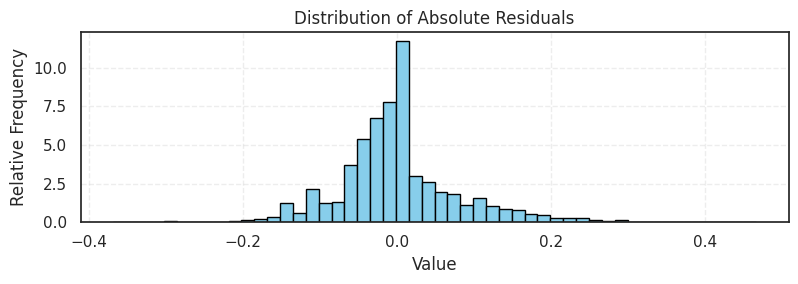

In [16]:
abs_diff = y_opt - y_pred

print(f"Moyenne des valeurs normales : {y_pred.mean():.5f}")
print(f"Moyenne des valeurs réelles : {y_opt.mean():.5f}")
print("")
print(f"Moyenne des résidus positifs (sous-estimation) : {abs_diff[abs_diff > 0].mean():.5f}")
print(f"Moyenne des résidus négatifs (sur-estimation) : {abs_diff[abs_diff < 0].mean():.5f}")

plt.figure(figsize=(8, 3))
plt.hist(abs_diff, bins=50, color='skyblue', edgecolor='black', density=True)
plt.title('Distribution of Absolute Residuals')
plt.xlabel('Value')
plt.ylabel('Relative Frequency')
plt.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

Malgré les différences de coefficients, les performances du modèle sur l'échantillon complet sont aussi bonnes que celles du modèle précédent.

# 2. Ecarts à la norme de représentativité selon les nuances politiques

In [17]:
plot_data = model_data_no_journal.copy()
plot_data['y_norm'] = compute_y_pred(
    plot_data,
    n, alpha, beta, gamma, theta,
    delta_pre_5, delta_pre_4, delta_pre_3, delta_pre_2, delta_pre_1, delta_pre_0,
    lambda_1, lambda_2)
plot_data['abs_residuals'] = 100 * (plot_data[outcome] - plot_data['y_norm'])
plot_data['month'] = plot_data['month'].dt.to_timestamp()

alignment_groups = [
    (['Far left', 'Far right', 'Other'],
     {'Far left': 'crimson',
      'Far right': 'royalblue',
      'Other': 'forestgreen'}),
    (['Right', 'Left', 'Center'],
     {'Right': 'cornflowerblue',
      'Left': 'orchid',
      'Center': 'goldenrod'})]

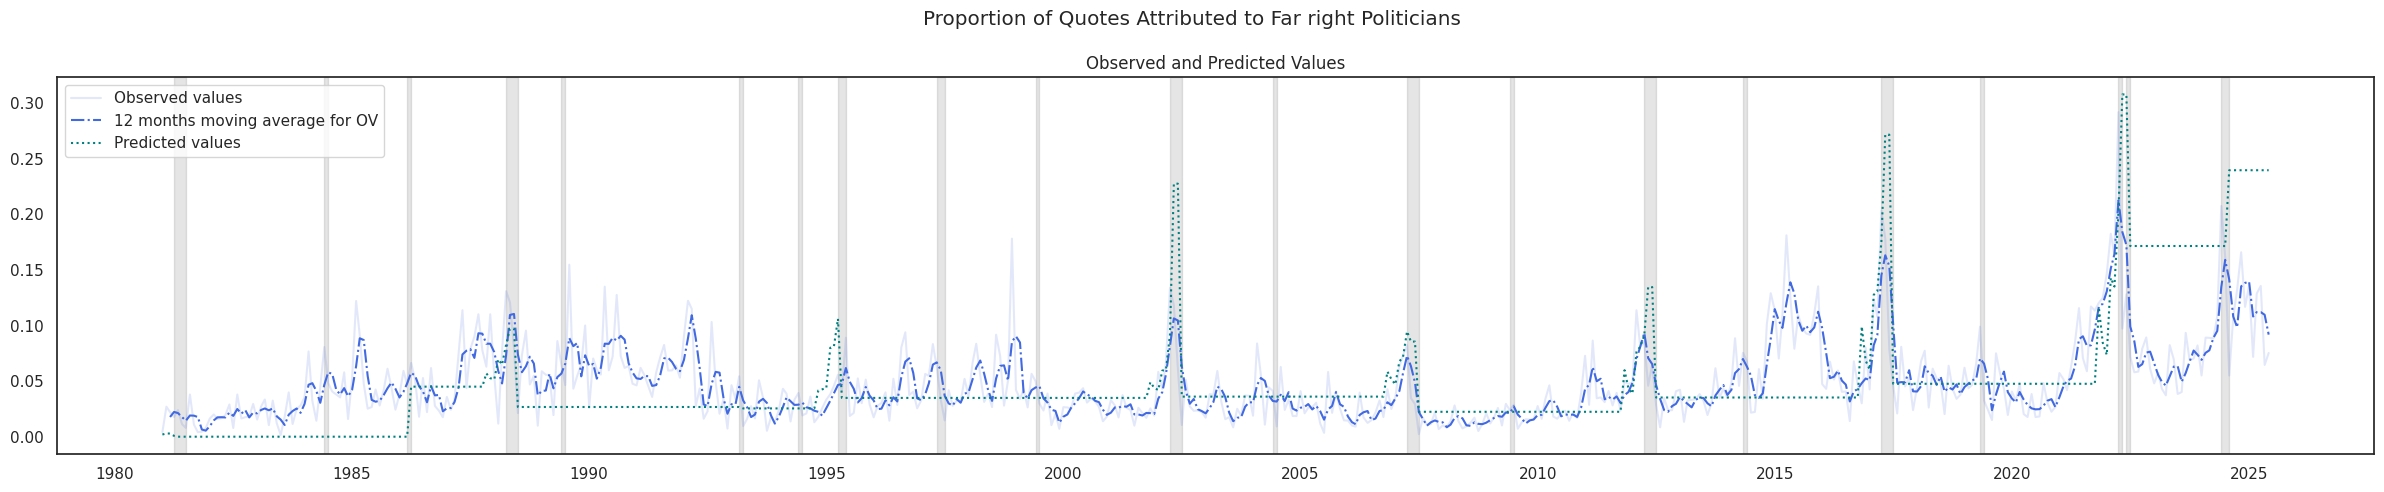

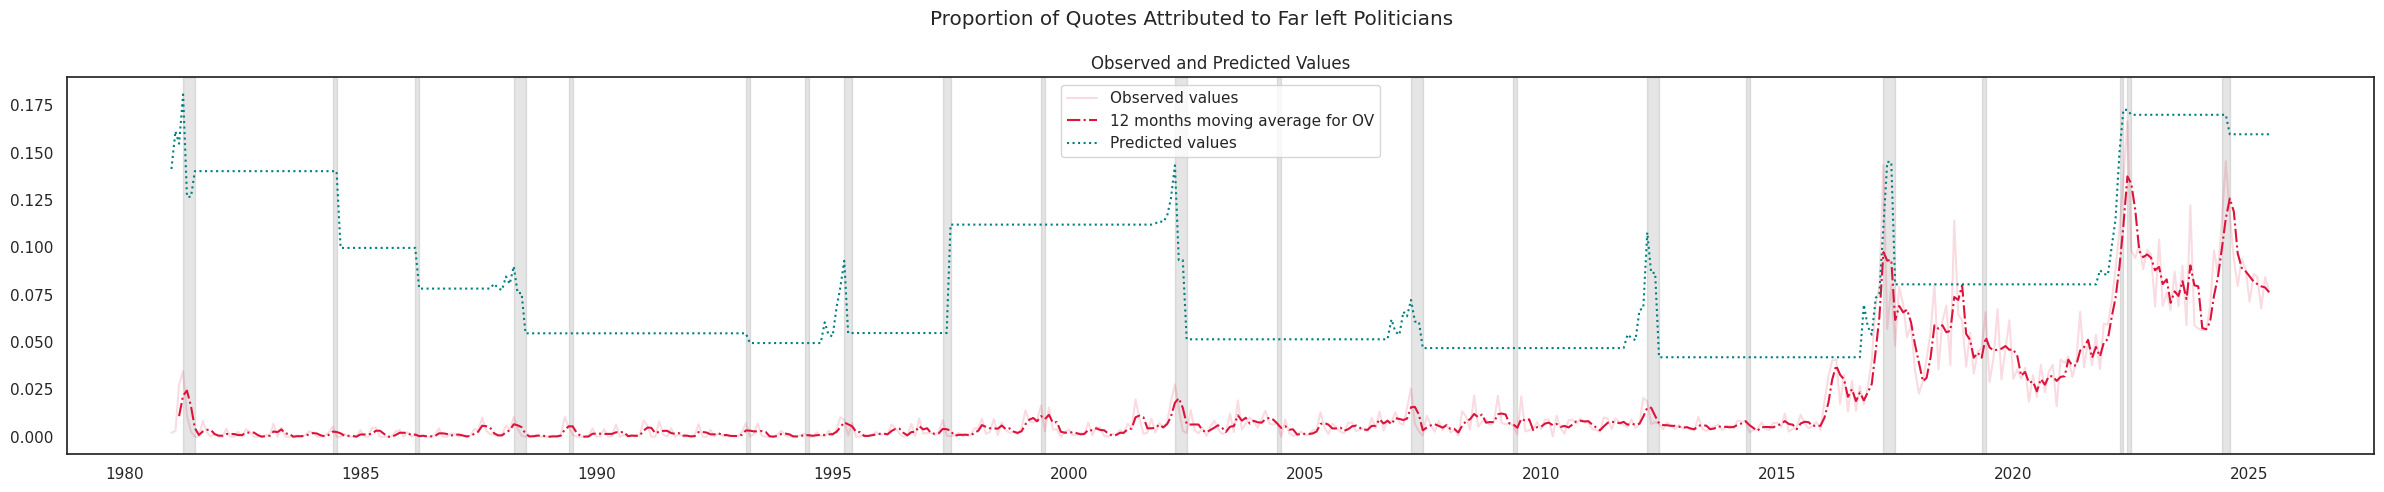

In [18]:
for alignment in ['Far right', 'Far left']:
    color = 'royalblue' if alignment == 'Far right' else 'crimson'
    subset_data = plot_data[plot_data['political_alignment'] == alignment].copy()
    subset_data['MA_observed'] = subset_data[outcome].rolling(window=3).mean()
    subset_data['MA_abs'] = subset_data['abs_residuals'].rolling(window=3).mean()

    fig, ax = plt.subplots(figsize=(24, 5))

    sns.lineplot(data=subset_data, x='month', y=outcome, ax=ax, label='Observed values', alpha=0.15, color=color, linestyle='-')
    sns.lineplot(data=subset_data, x='month', y='MA_observed', ax=ax, label='12 months moving average for OV', color=color, linestyle='dashdot')
    sns.lineplot(data=subset_data, x='month', y='y_norm', ax=ax, label='Predicted values', color='teal', linestyle='dotted')
    ax.set_title("Observed and Predicted Values")
    ax.set_ylabel('')
    ax.set_xlabel('')

    add_shaded_periods([ax], main_elec_months, color='black', alpha=0.1)

    plt.suptitle(f"Proportion of Quotes Attributed to {alignment} Politicians")
    plt.tight_layout()
    plt.savefig(f"output/{alignment}_graph.png", dpi=300, bbox_inches='tight')
    plt.show()

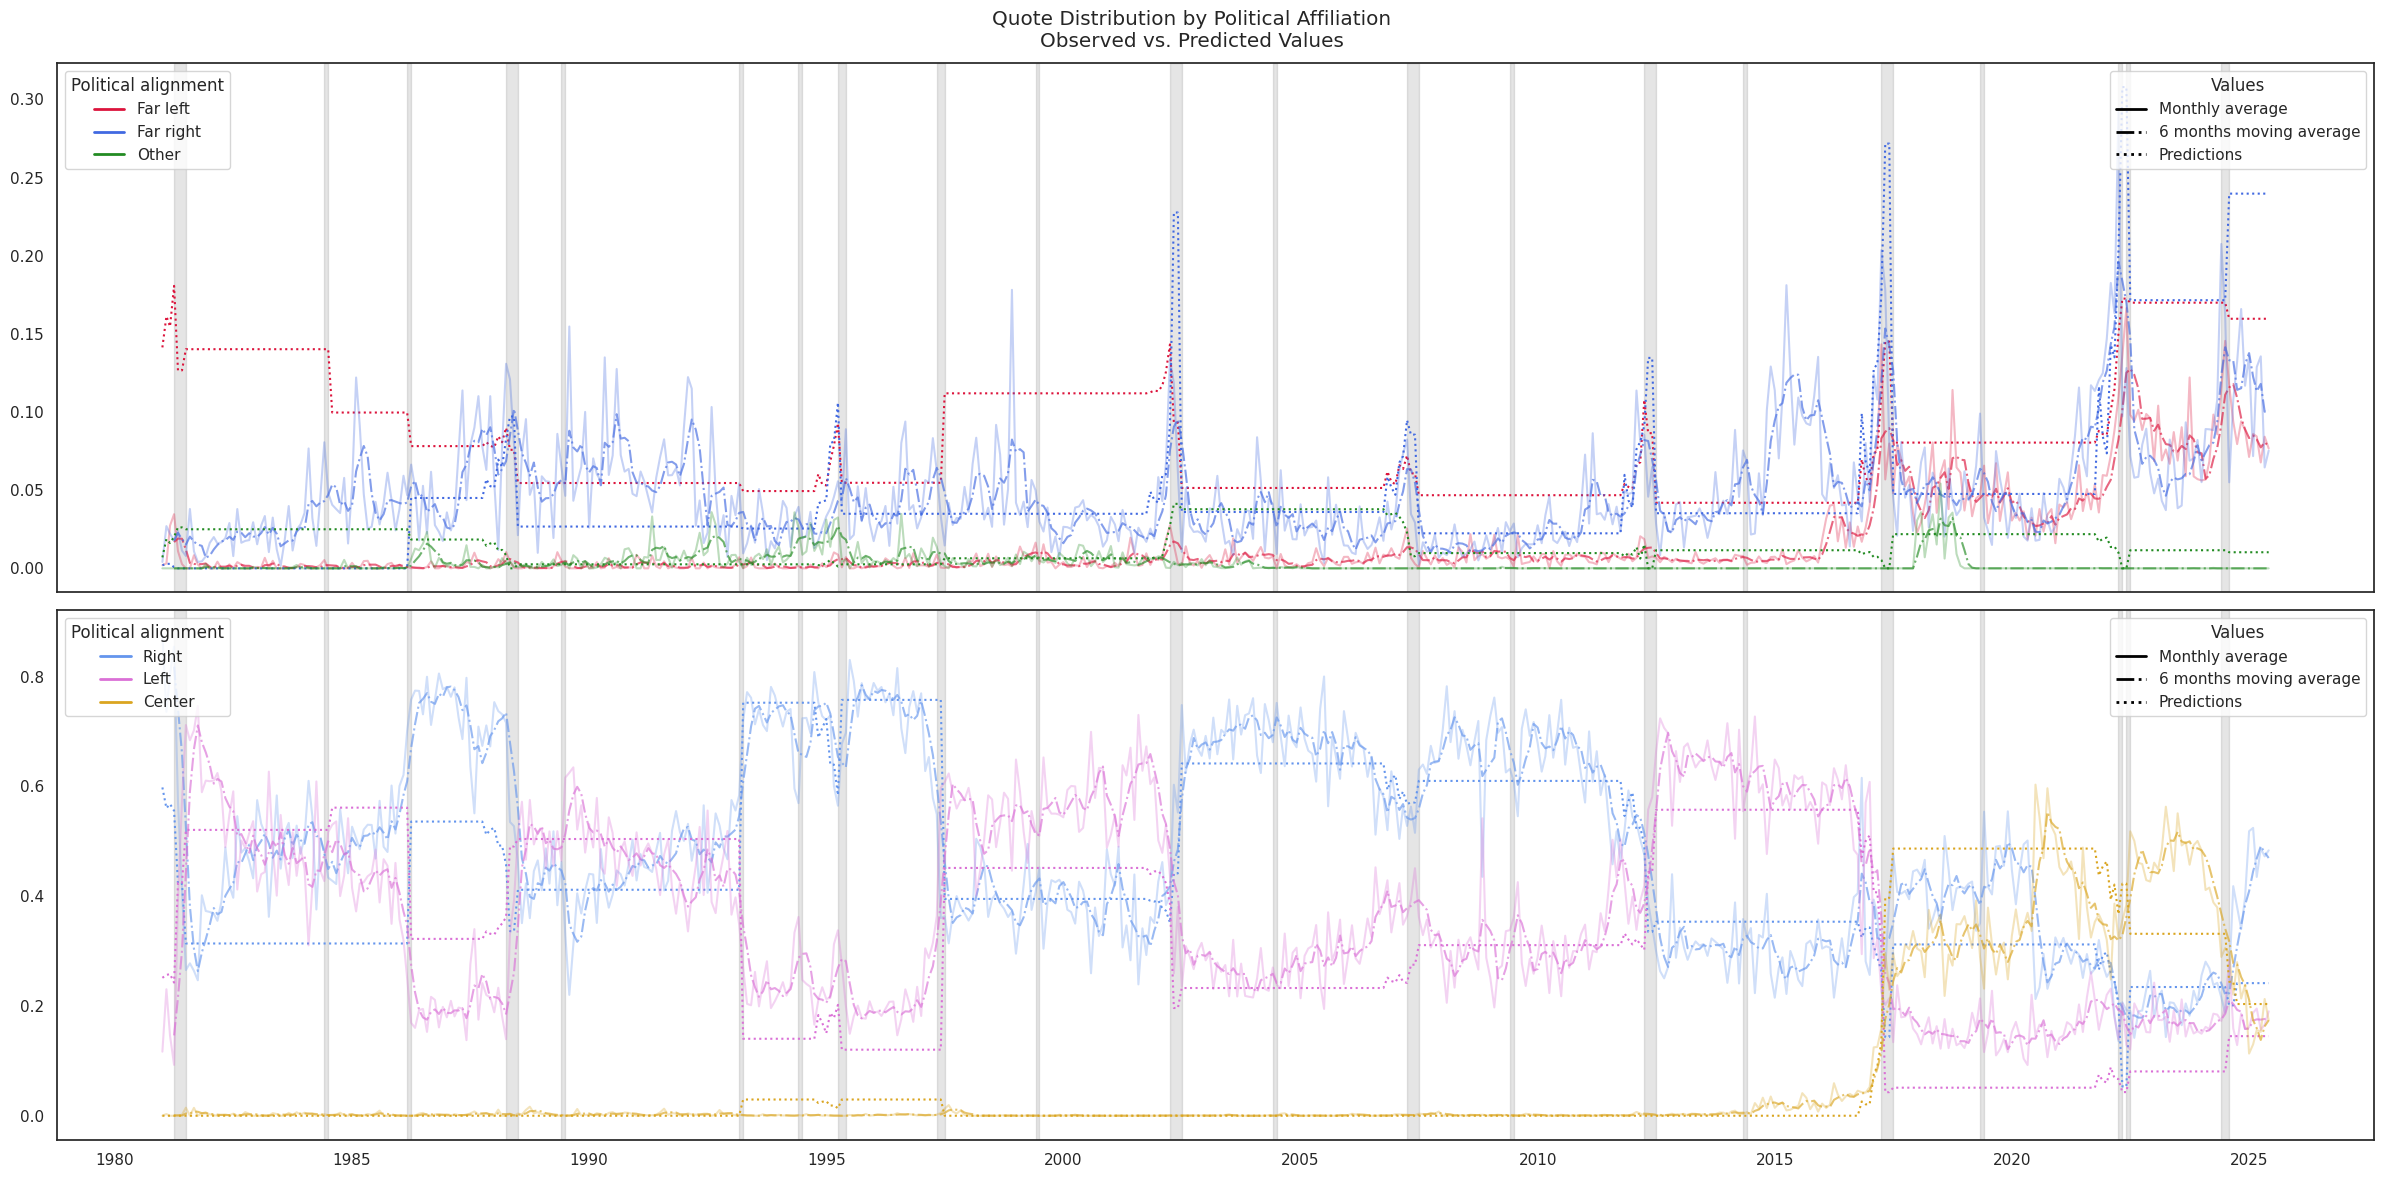

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(24, 12), sharex=True)

for ax, (political_alignments, colors) in zip(axes, alignment_groups):
    alignment_handles = []

    for alignment in political_alignments:
        subset_data = plot_data[plot_data['political_alignment'] == alignment].copy()
        subset_data['MA'] = subset_data[outcome].rolling(window=4).mean()
        
        ax.plot(subset_data['month'], subset_data[outcome], label=None,
                alpha=0.3, color=colors[alignment], linestyle='-')
        ax.plot(subset_data['month'], subset_data['MA'], label=None,
                alpha=0.65, color=colors[alignment], linestyle='dashdot')
        ax.plot(subset_data['month'], subset_data['y_norm'], label=None,
                alpha=1, color=colors[alignment], linestyle='dotted')
        
        alignment_handles.append(Line2D([0], [0], color=colors[alignment], lw=2, label=alignment))

    alignment_legend = ax.legend(handles=alignment_handles, title="Political alignment", loc="upper left")
    ax.add_artist(alignment_legend)

    line_type_handles = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label="Monthly average"),
        Line2D([0], [0], color='black', lw=2, linestyle='dashdot', label="6 months moving average"),
        Line2D([0], [0], color='black', lw=2, linestyle='dotted', label="Predictions")]
    ax.legend(handles=line_type_handles, title="Values", loc="upper right")

axes[-1].set_xlabel("")

add_shaded_periods(axes, main_elec_months, color='black', alpha=0.1)

plt.suptitle("Quote Distribution by Political Affiliation\nObserved vs. Predicted Values")
plt.tight_layout()
plt.savefig("output/nuances_val_graph.png", dpi=300, bbox_inches='tight')
plt.show()

1984 = le PCF quitte le gouvernement. Tout se passe comme si les citations correspondantes allaient à la gauche plutôt qu'à la gauche radicale.

1986 = changement de majorité et de gouvernement sans lien avec une élection présidentielle. Le trend précédent, non-reflété par le modèle, pourrait venir des sondages.

1993 = de même

1995 en particulier = le pic négatif pour la droite, et les pics positifs pour les autres partis, sont attendus. En période électorale, la couverture du parti dominant se réduit fatalement pour laisser la place aux challengers.

2002 = forme heurtée de la courbe pour la gauche lors de l'élection présidentielle = car absente du second tour

2007 = idem pour l'extrême droite, fait de bon scores dans les sondages mais n'accède pas au premier tour

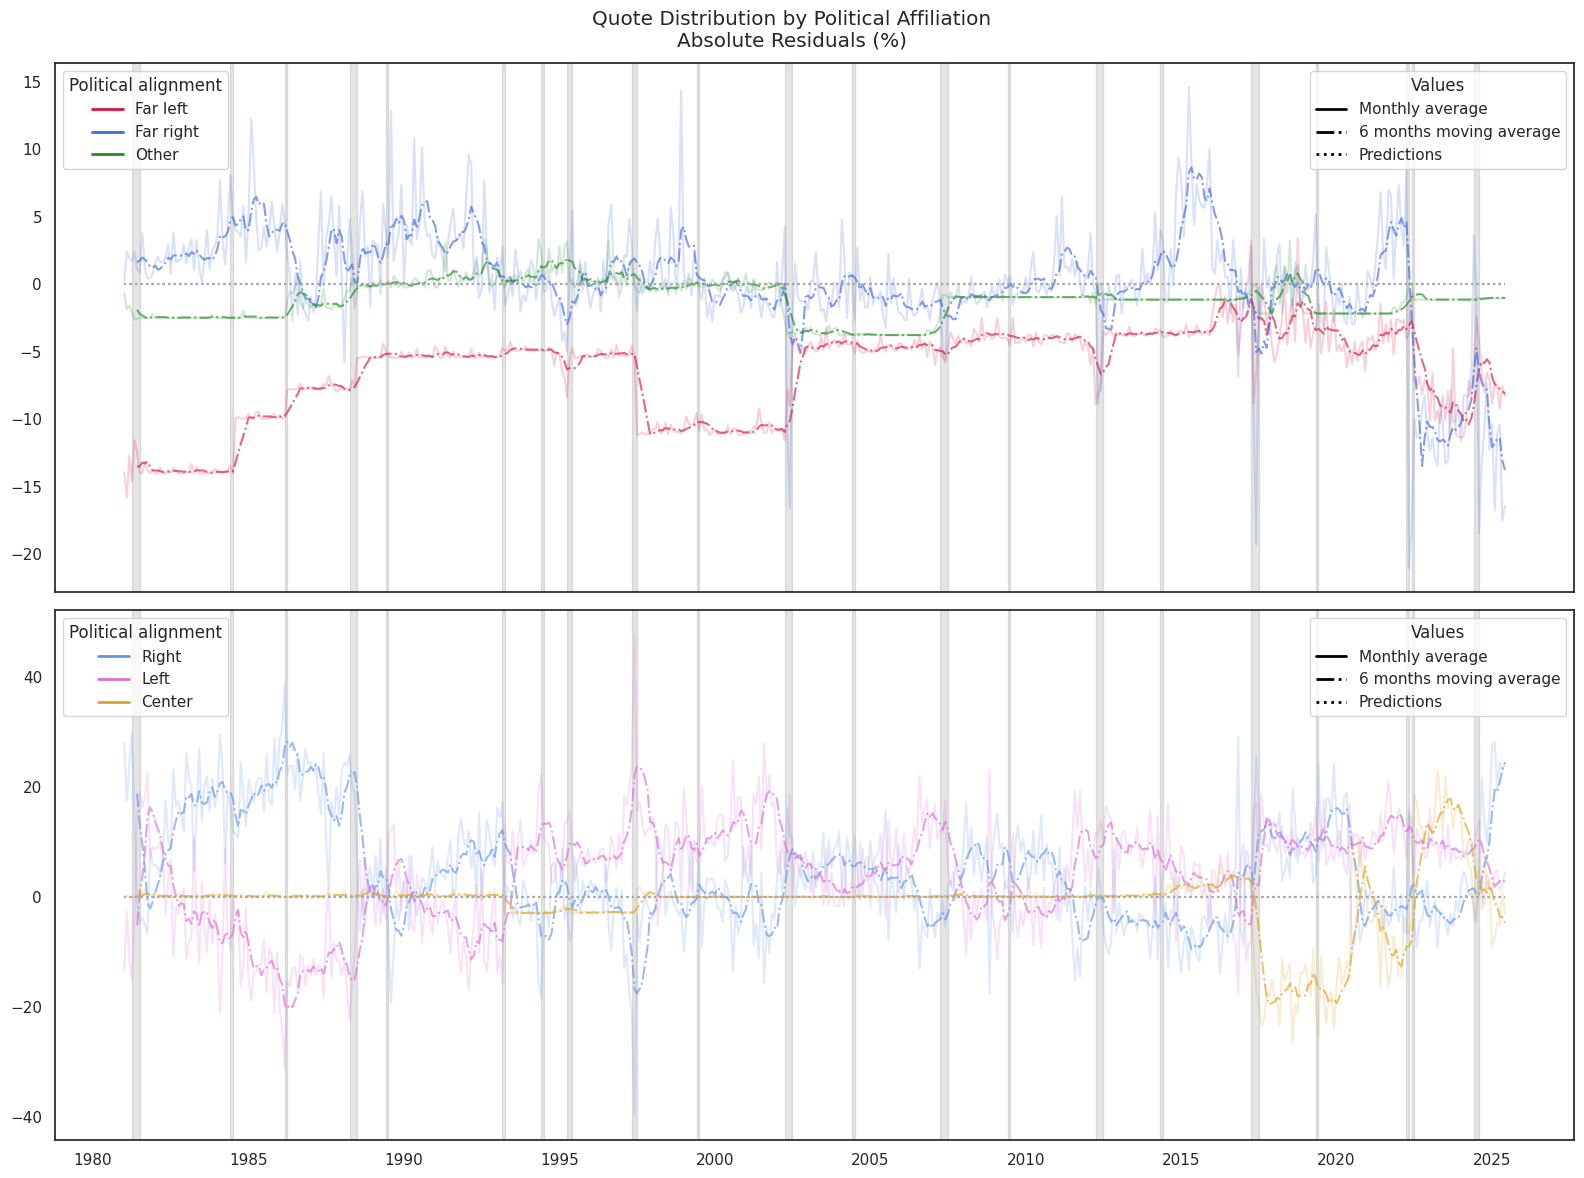

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

for ax, (political_alignments, colors) in zip(axes, alignment_groups):
    alignment_handles = []

    for alignment in political_alignments:
        subset_data = plot_data[plot_data['political_alignment'] == alignment].copy()
        subset_data['MA'] = subset_data['abs_residuals'].rolling(window=6).mean()
        
        ax.plot(subset_data['month'], subset_data['abs_residuals'], label=None,
                alpha=0.2, color=colors[alignment], linestyle='-')
        ax.plot(subset_data['month'], subset_data['MA'], label=None,
                alpha=0.65, color=colors[alignment], linestyle='-.')
        ax.plot(subset_data['month'], [0] * len(subset_data), label=None,
                alpha=1, color='darkgray', linestyle=':')
        
        alignment_handles.append(Line2D([0], [0], color=colors[alignment], lw=2, label=alignment))

    alignment_legend = ax.legend(handles=alignment_handles, title="Political alignment", loc="upper left")
    ax.add_artist(alignment_legend)

    line_type_handles = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label="Monthly average"),
        Line2D([0], [0], color='black', lw=2, linestyle='-.', label="6 months moving average"),
        Line2D([0], [0], color='black', lw=2, linestyle=':', label="Predictions")
    ]
    ax.legend(handles=line_type_handles, title="Values", loc="upper right")

axes[-1].set_xlabel("")

add_shaded_periods(axes, main_elec_months, color='black', alpha=0.1)

plt.suptitle("Quote Distribution by Political Affiliation\nAbsolute Residuals (%)")
plt.tight_layout()
plt.savefig("output/nuances_abs_graph.png", dpi=300, bbox_inches='tight')
plt.show()

Le résultat le plus flagrant est la présence de deux dynamiques non-capturées : 
- L'une pour l'extrême-droite entre 1983 et 1985. L'année 1984 correspond au premier succès du Front national lors d'une élection nationale. Or, il s'agit des européennes, dont les résultats ne sont pas intégrés notre modèle normatif. Lorsque l'on exclut la période correspondante, les MAPE du modèle *a priori* deviennent équivalente pour l'extrême droite et l'extrême gauche (mais avec des MRR toujours bien plus négatifs pour la seconde) (cf. *infra*).
- L'autre pour le centre entre 2007 et 2017. Ici, le décalage entre les comportements réels et prescrits est plus difficilement explicable. L'année 2007 est marquée par la percée de François Bayrou lors des élections présidentielles, qui arrive 3e avec 18,57 % des voix, et l'année 2017 par la victoire d'Emmanuel Macron à ces mêmes élections. Mais les résultats de ces dernières sont bien pris en compte par notre modèle normatif. Alors... ? Observons nous ici un fort engagement des rédactions en faveur du centre ? Ou cette impression résulte-t-elle de problèmes dans les données ?

On constate aussi l'existence d'une prime à la majorité pour les partis accédant au pouvoir, qui reçoivent toujours davantage de citations que prescrit pas notre modèle. Mais curieusement, l'ajout de la nuance politique du Premier ministre aux modèles estimés n'améliore pas leurs performances prédictives (cf. *infra*).

Enfin, aucun biais systématique n'apparaît dans la couverture médiatique des nuances politiques, sauf en défaveur de l'extrême gauche.

*Tentative pour calculer la proportion des proportions de citations correctement prescrites...*
- *Correct prescriptions = proportion des citations prescrites correspondant à des citations réelles*
- *Excess prescriptions = proportion des citations prescrites excédant les citations réelles*
- *True missing = proportion des citations réelles non-prescrites par le modèle a priori*

In [21]:
def compute_proportional_metrics(y_norm, y_true):
    y_norm = np.array(y_norm)
    y_true = np.array(y_true)
    
    # Initialize arrays
    TP = np.zeros_like(y_norm)
    TN = np.zeros_like(y_norm)
    FP = np.zeros_like(y_norm)
    FN = np.zeros_like(y_norm)
    
    # Calculate difference
    diff = y_norm - y_true
    
    # Case 1: y_norm - y_true = 0 (perfect prediction)
    perfect_mask = (diff == 0)
    TP[perfect_mask] = 1
    FP[perfect_mask] = 0
    FN[perfect_mask] = 0
    
    # Case 2: y_norm - y_true > 0 (over-prediction)
    over_mask = (diff > 0)
    TP[over_mask] = y_true[over_mask] / y_norm[over_mask]
    FP[over_mask] = diff[over_mask] / y_norm[over_mask]
    FN[over_mask] = 0
    
    # Case 3: y_norm - y_true < 0 (under-prediction)
    under_mask = (diff < 0)
    TP[under_mask] = 1
    FN[under_mask] = - diff[under_mask] / y_true[under_mask]
    FP[under_mask] = 0
    
    return {
        'TP': TP.mean(),
        'FP': FP.mean(),
        'FN': FN.mean()}

summary_list = []

for alignment in model_data_no_journal['political_alignment'].unique():
    subset_data = model_data_no_journal[model_data_no_journal['political_alignment'] == alignment]
    y = subset_data[outcome]
    y_norm = subset_data['y_norm']
    metrics = compute_proportional_metrics(y_norm, y)
    summary_list.append({
        'Political alignment': alignment,
        '% correct prescriptions': 100 * metrics['TP'],
        '% excess prescriptions': 100 * metrics['FP'],
        '% missing prescriptions': 100 * metrics['FN']})

summary = pd.DataFrame(summary_list)
summary["Political alignment"] = pd.Categorical(summary["Political alignment"], categories=nuances_order, ordered=True)
summary.style.hide(axis="index").format({col: "{:.2f}" for col in summary.columns[1:]})

KeyError: 'y_norm'

# 2. Ecarts à la norme de représentativité selon les journaux

In [ ]:
plot_data = model_data.copy()
plot_data['y_norm'] = compute_y_pred(
    plot_data,
    n, alpha, beta, gamma, theta,
    delta_pre_5, delta_pre_4, delta_pre_3, delta_pre_2, delta_pre_1, delta_pre_0,
    lambda_1, lambda_2)
plot_data['abs_residuals'] = 100 * (plot_data[outcome] - plot_data['y_norm'])
plot_data['month'] = plot_data['month'].dt.to_timestamp()

Trois groupes de journaux apparaissent :
- Le Figaro et Le Monde respectent le plus la norme de représentativité
- La Croix et Libération la respectent un peu moins
- Médiapart s'en écarte plus franchement

Le traitement du centre par La Croix et de la gauche par Libération semble responsable de leur déviation supérieure par rapport au Monde et au Figaro. Médiapart se distingue en citant davantage l'extrême gauche, mais plus encore l'extrême droite.

In [ ]:
fig, axes = plt.subplots(n_alignments, 1, figsize=(24, 4 * n_alignments), sharex=True)

for i, alignment in enumerate(alignments):
    ax = axes[i]
    subset_data = plot_data[plot_data['political_alignment'] == alignment]

    for journal in subset_data['journal'].unique():
        if journal == 'Médiapart': continue
        sub_subset_data = subset_data[subset_data['journal'] == journal].copy()
        sub_subset_data['MA'] = sub_subset_data[outcome].rolling(window=12).mean()
        ax.plot(sub_subset_data['month'], sub_subset_data[outcome], label=journal,
                alpha=0.7, color=colors[journal], linestyle='-')

    ax.plot(subset_data['month'], subset_data['y_norm'], color='black', alpha=0.8, linestyle='dotted')
    ax.set_title(f"{alignment}")
    ax.legend()

add_shaded_periods(axes, main_elec_months, color='black', alpha=0.1)

plt.suptitle("""
Quote Distribution by Political Affiliation and Journal\n
Observed vs. Predicted Values
""")
plt.tight_layout()
plt.savefig("output/journals_val_graph.png", dpi=300, bbox_inches='tight')
plt.show()

Médiapart est exclu des graphs car ses données semblent assez erratiques jusqu'en 2012 : le nombre d'articles publiés est probablement faible, ce qui conduit à atteindre régulièrement des proportions de 1 pour certaines nuances politiques.

On retrouve de manière plus visible que dans le tableau les différences éditoriales auxquelles on pouvait s'attendre : le Figaro et la Croix couvrent davantage la droite que le Monde et Libération, et inversement pour la gauche et l'extrême gauche. Concernant l'extrême droite, aucune différence flagrante n'apparaît.